# 01 · Exploratory Data Analysis

**Dataset:** UNSW-NB15 *official train/test release* (175,341 + 82,332 flows, 45 columns). This release has **no srcip/dstip, ports or timestamps**, so IP-level and time-based analysis is replaced by segment- and behaviour-based substitutes throughout the project.

This notebook calls `src/eda.py`, which loads the CSVs in chunks with downcast dtypes, profiles them and saves figures to `reports/figures/`.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
SRC = Path.cwd().parent / 'src' if (Path.cwd().parent / 'src').exists() else Path.cwd() / 'src'
sys.path.insert(0, str(SRC))
import pandas as pd, json
from IPython.display import Image, Markdown, display
from config import FIG_DIR, METRICS_DIR, REPORTS_DIR, EXPORT_DIR
pd.set_option('display.max_columns', 60, 'display.width', 200)
def show(name, width=900):
    display(Image(filename=str(FIG_DIR / f'{name}.png'), width=width))

In [2]:
import eda
profile = eda.run()


PHASE 2 - EDA
Dataset version: train_test (no srcip/dstip/ports/Stime/Ltime in this release)


                      file  size_mb  data_rows                                                                       first_line
    NUSW-NB15_features.csv     0.00         49                                                       No.,Name,Type ,Description
 UNSW_NB15_testing-set.csv    15.38      82332 id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,
UNSW_NB15_training-set.csv    32.29     175341 id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,


Shape [257673, 46], memory 49.2 MB, nulls 0, duplicates (within split, excl. id) 93,824


Normal vs attack: {'Attack': 164673, 'Normal': 93000}
Attack share by split: {'test': 0.5506, 'train': 0.6806}
Attack categories: {'Normal': 93000, 'Generic': 58871, 'Exploits': 44525, 'Fuzzers': 24246, 'DoS': 16353, 'Reconnaissance': 13987, 'Analysis': 2677, 'Backdoor': 2329, 'Shellcode': 1511, 'Worms': 174}
proto=133 distinct, service=13, state=11


## Data profile
Shape, memory, nulls and duplicates (duplicates = feature-identical rows ignoring `id`).

In [3]:
{k: profile[k] for k in ['shape','memory_mb','null_total','duplicate_rows_within_split','rows_by_split','attack_share_by_split']}

{'shape': [257673, 46],
 'memory_mb': np.float64(49.2),
 'null_total': 0,
 'duplicate_rows_within_split': 93824,
 'rows_by_split': {'train': 175341, 'test': 82332},
 'attack_share_by_split': {'test': 0.5506, 'train': 0.6806}}

## Normal vs attack
Attacks are the *majority* class in both splits, and the test split has a noticeably higher normal share - a distribution shift that later shows up as false positives.

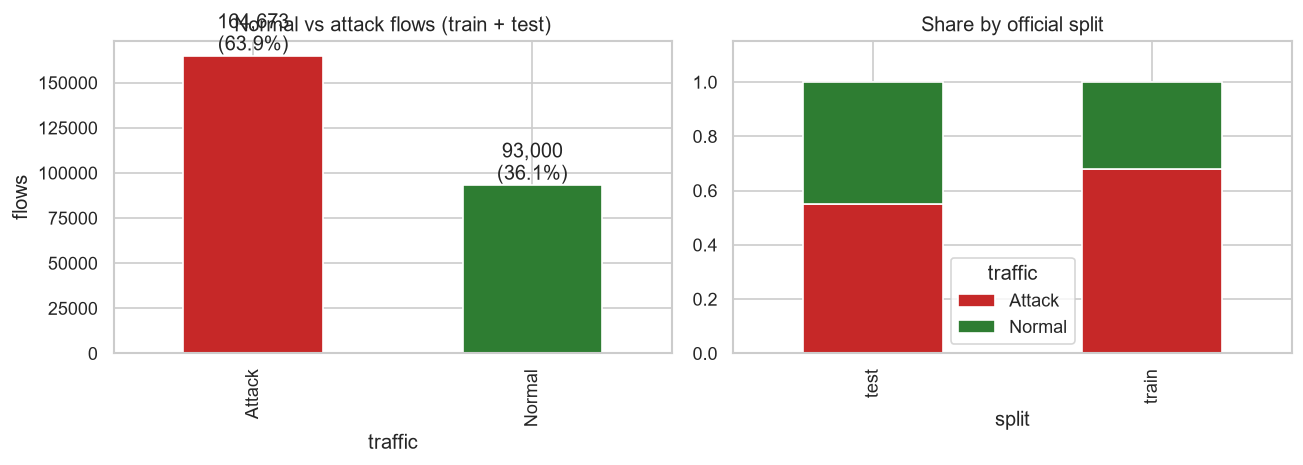

In [4]:
show('02_normal_vs_attack')

## Attack categories
Heavily imbalanced: Generic and Exploits dominate; Worms has only a few hundred flows.

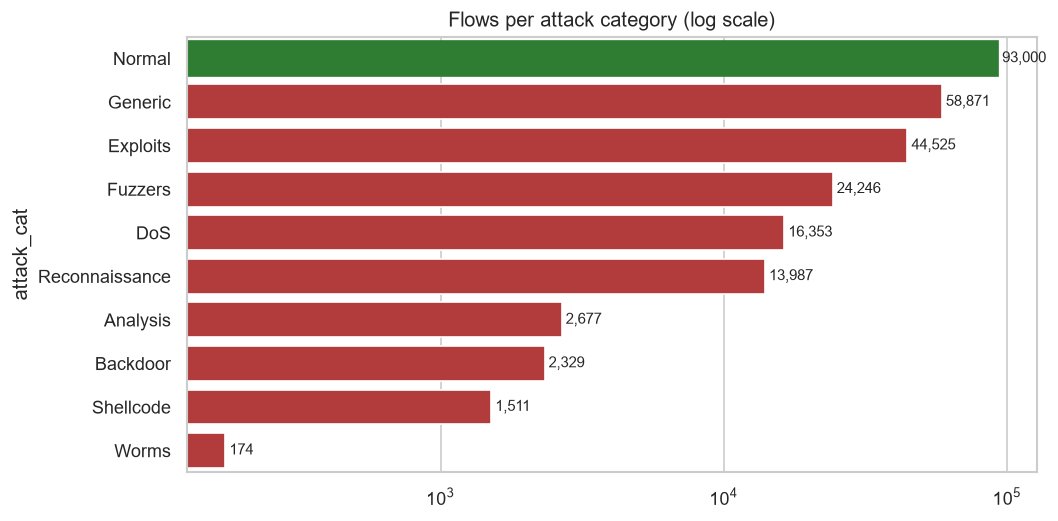

In [5]:
show('02_attack_categories', 700)

## Protocol, service and state
`service='-'` means no application protocol was identified.

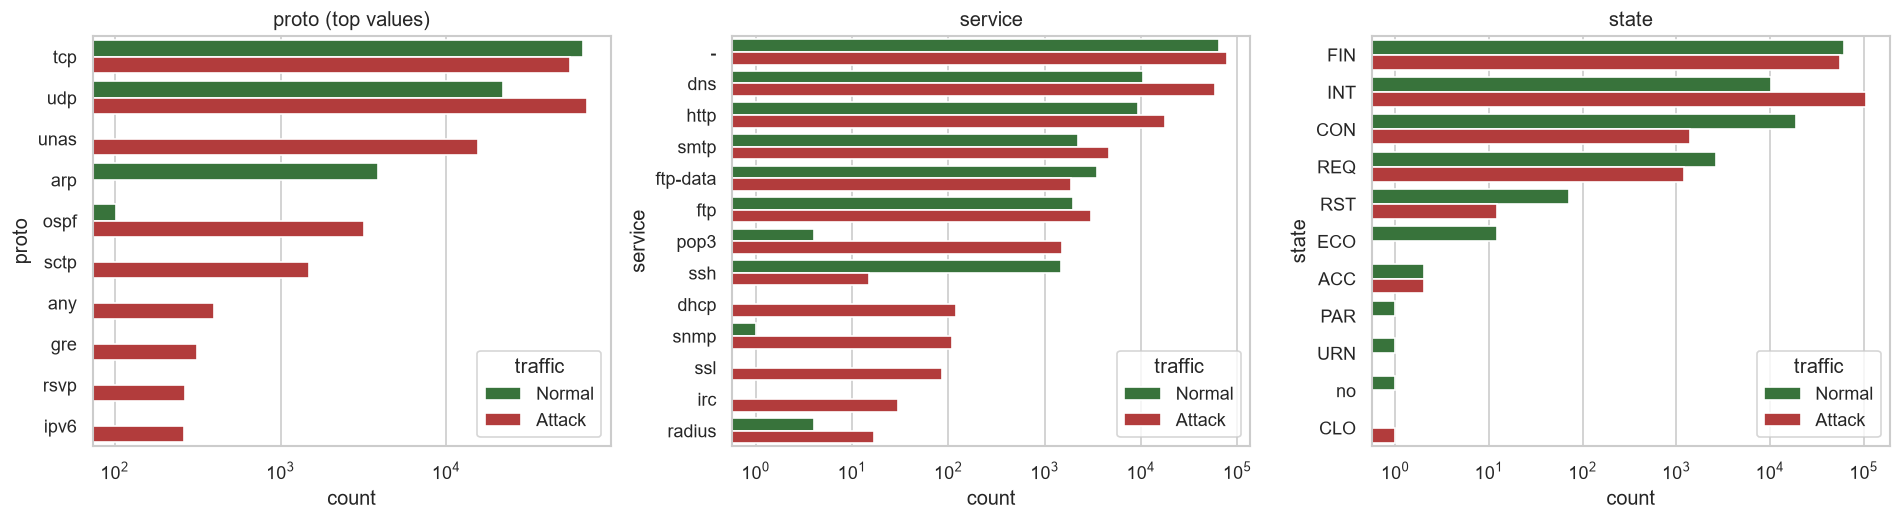

In [6]:
show('02_proto_service_state', 1100)

## Log-scale distributions
Bytes, packets and duration span many orders of magnitude, so models use `log1p` transforms.

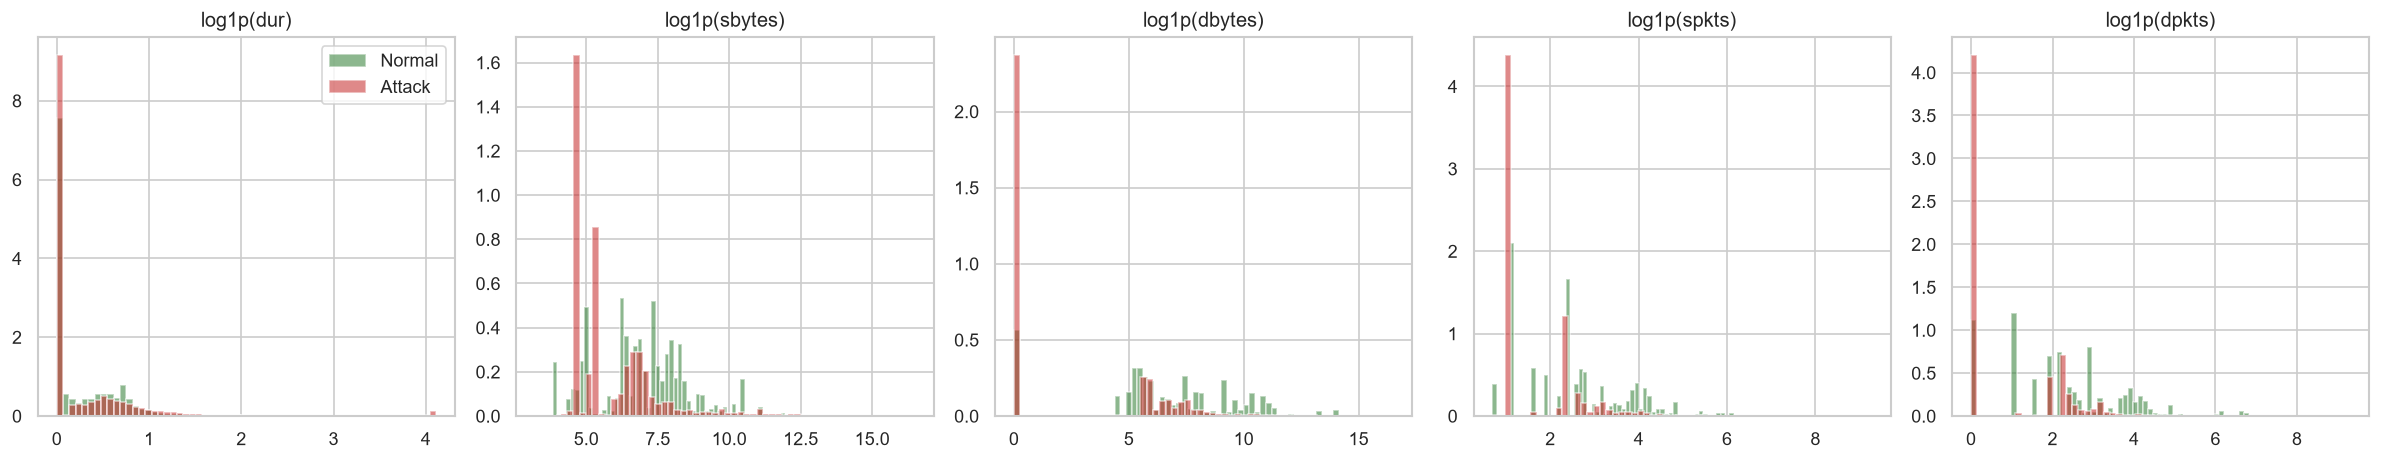

In [7]:
show('02_log_distributions', 1100)